In [ ]:
# Marketing ROI Analysis Using Simple Linear Regression

## Project Overview

This project analyzes the relationship between marketing expenditure and sales using Simple Linear Regression. The objective is to identify the marketing channel most strongly associated with sales performance and provide data-driven recommendations for marketing budget allocation.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load dataset
df = pd.read_csv('marketing_and_sales_data_evaluate_Ir.csv')

print("Dataset loaded successfully.")
print("Rows and Columns:", df.shape)

Dataset loaded successfully.
Rows and Columns: (4572, 4)


In [ ]:
## Dataset Preview

The first five rows of the dataset were displayed to verify that the dataset was loaded correctly and to understand the available variables.

In [18]:
print(df.head())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


In [ ]:
## Dataset Structure

The dataset structure was examined to determine the number of observations, variable types, and the presence of missing values.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 142.9 KB


In [ ]:
## Missing Value Assessment

Missing values were identified in the dataset. Since regression analysis requires complete observations, the extent of missing data was assessed before cleaning.

In [20]:
print(df.isnull().sum())

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [ ]:
## Data Cleaning

The dataset contained a very small proportion of missing values. Therefore, rows containing missing values were removed using the dropna() function to ensure reliable analysis.

In [21]:
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())

Dataset shape after cleaning: (4546, 4)

Missing values remaining:
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


In [ ]:
## Descriptive Statistics

Descriptive statistics were generated to summarize the central tendency and variability of the variables in the dataset.

In [22]:
print(df.describe())

                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.555355      1.530822   112.434612
50%      53.000000    17.859513      3.055565   188.963678
75%      77.000000    25.640603      4.804919   272.324236
max     100.000000    48.871161     13.981662   364.079751


In [ ]:
## Exploratory Data Analysis

Scatter plots were used to visualize the relationship between each advertising channel and Sales. This helps identify potential predictors for the regression model.

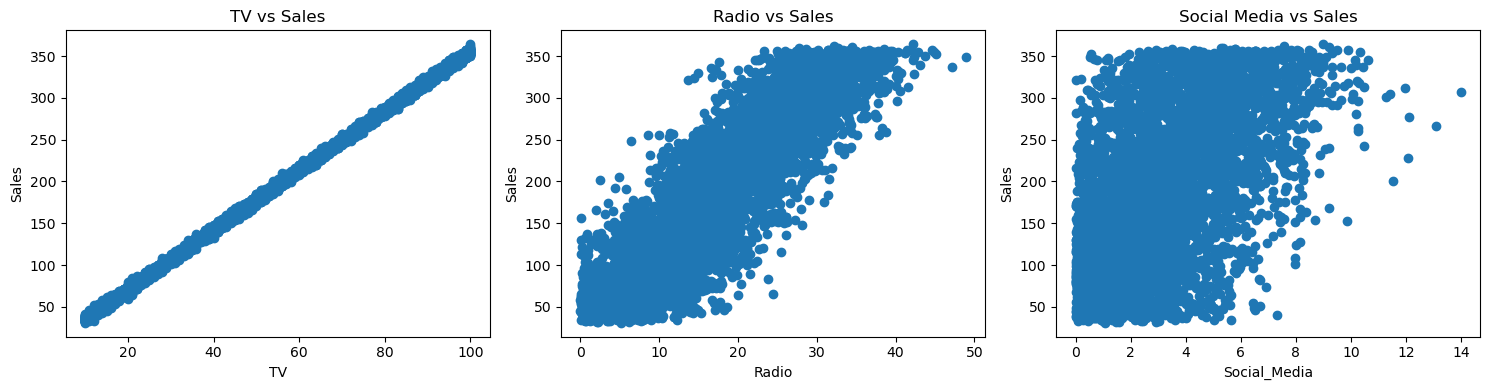

In [23]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')

plt.subplot(1,3,2)
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio vs Sales')

plt.subplot(1,3,3)
plt.scatter(df['Social_Media'], df['Sales'])
plt.xlabel('Social_Media')
plt.ylabel('Sales')
plt.title('Social Media vs Sales')

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Analysis

Correlation coefficients were calculated to identify the marketing channel most strongly associated with Sales.

In [24]:
correlation_matrix = df.corr()

print(correlation_matrix['Sales'].sort_values(ascending=False))

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [ ]:
## Variable Selection

TV advertising expenditure exhibited the highest correlation with Sales (0.9995). Therefore, TV was selected as the independent variable for the Simple Linear Regression model.

In [ ]:
## Building the Regression Model

An Ordinary Least Squares (OLS) Simple Linear Regression model was developed using TV advertising expenditure as the independent variable and Sales as the dependent variable.

In [25]:
X = df['TV']
y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:48:26   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [ ]:
## Diagnostic Plot: Residuals vs Fitted Values

The Residuals vs Fitted Values plot was used to assess the assumptions of linearity and homoscedasticity.

In [ ]:
predictions = model.predict(X)
residuals = y - predictions

plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [ ]:
## Assessment of Linearity and Homoscedasticity

The residuals were randomly distributed around zero with no obvious systematic pattern. The spread of residuals remained relatively constant across fitted values, indicating that the assumptions of linearity and homoscedasticity were satisfied.

In [ ]:
## Histogram of Residuals

A histogram of residuals was generated to assess whether the residuals were approximately normally distributed.

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

In [ ]:
## Assessment of Normality

The histogram exhibited an approximately bell-shaped distribution centered around zero, indicating that the residuals were approximately normally distributed.

In [ ]:
## Q-Q Plot

A Q-Q plot was generated to further evaluate the normality assumption.

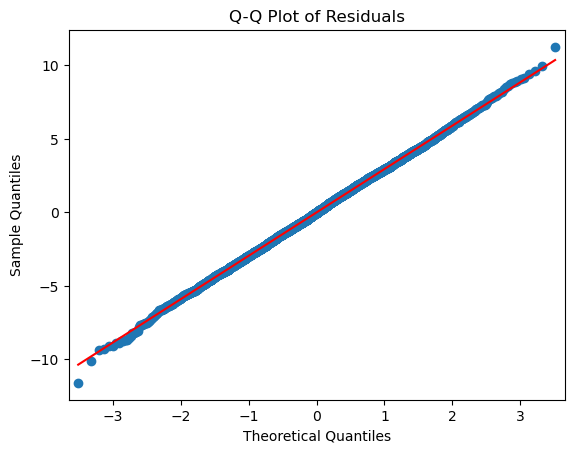

In [26]:
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

In [ ]:
## Assessment of Q-Q Plot

The residuals closely followed the reference line, indicating that the normality assumption was satisfied.

In [ ]:
## Model Interpretation

The regression model achieved an R-squared value of 0.999, indicating that approximately 99.9% of the variation in Sales is explained by TV advertising expenditure.

The coefficient for TV advertising was 3.5615, indicating that a one-unit increase in TV advertising expenditure is associated with an increase of approximately 3.56 units in Sales.

The p-value for TV advertising was less than 0.001, indicating that TV advertising is a statistically significant predictor of Sales.

In [ ]:
## Marketing ROI Recommendation

TV advertising demonstrated the strongest relationship with Sales and the highest predictive power among all marketing channels.

Based on the results, organizations seeking to maximize return on investment should prioritize TV advertising expenditure while using Radio and Social Media as supplementary channels.

In [ ]:
## Conclusion

This project applied Simple Linear Regression to evaluate the impact of marketing expenditure on Sales.

After data cleaning, exploratory analysis, correlation analysis, regression modeling, and diagnostic testing, TV advertising was identified as the strongest predictor of Sales. The model satisfied the assumptions of linearity, homoscedasticity, and normality and demonstrated exceptional predictive performance.

The findings suggest that increasing investment in TV advertising is likely to generate the greatest impact on Sales and should be prioritized in future marketing budget allocation decisions.